# Quantum Algorithms on the LHCb VELO Toy — First Benchmark

**Goal.** Show that the three solvers — the classical direct sparse
solver, the full **HHL** algorithm, and the **1-Bit HHL** (`OneBitHHL`)
— can all reconstruct tracks from the toy-model step-function
Hamiltonian, and characterise how each of them degrades as a **single**
noise knob is varied.

**Hamiltonian.** `SimpleHamiltonian` with `convolution=False`
⇒ hard step-function angular compatibility at threshold $\varepsilon$.

**One-parameter scans.** Each section below varies only one of

1. $\sigma_{\mathrm{scatter}}$ — multiple scattering,
2. $\sigma_{\mathrm{res}}$ — hit position resolution,
3. $n_{\mathrm{tracks}}$ — event multiplicity (1 … 10),

with all other parameters fixed at the reference point defined in §0.

**Outputs per scan.** One summary figure (efficiency + ghost-rate panels)
plus one compact mean ± SEM table. Raw per-event CSVs are written to
`outputs/first_bench/` for later re-analysis.


## 0. Setup


In [1]:
from __future__ import annotations
import math, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d proj)

warnings.filterwarnings("ignore", category=DeprecationWarning)

from lhcb_velo_toy.generation import PlaneGeometry, StateEventGenerator
from lhcb_velo_toy.solvers import SimpleHamiltonian, get_tracks
from lhcb_velo_toy.solvers.classical import solve_direct
from lhcb_velo_toy.solvers.quantum.hhl import HHLAlgorithm
from lhcb_velo_toy.solvers.quantum.one_bit_hhl import OneBitHHL
from lhcb_velo_toy.analysis import EventValidator

OUT = Path("/data/bfys/gscriven/Quantum_Track_Reconstruction/"
           "Toy_Characterisation/Quantum_Toy_Study/outputs/first_bench")
(OUT / "plots").mkdir(parents=True, exist_ok=True)
np.random.seed(20260421)

# Algorithm labels + colours used everywhere
ALGOS = ["Classical (solve_direct)", "HHL (full)", "OneBitHHL"]
ALGO_COLOURS = {"Classical (solve_direct)": "#222222",
                "HHL (full)":                "#D62728",
                "OneBitHHL":                 "#1F77B4"}

print("Imports OK.  Output dir:", OUT)


Imports OK.  Output dir: /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Quantum_Toy_Study/outputs/first_bench


In [ ]:
# ── Reference configuration (middle of every scan) ─────────────────
N_MODULES   = 3
DZ_MM       = 33.0
Z_FIRST_MM  = 33.0
HALF_XY_MM  = 40.0

# SimpleHamiltonian parameters (OneBQF paper: alpha=2, beta=1)
GAMMA       = 2.0
DELTA       = 1.0
SCALE       = 3.0
THETA_MIN   = 1.5e-5

# Segment-activation threshold as a fraction of max(|x|) (OneBQF paper: 0.45)
ACT_THRESH_FRAC = 0.45

REF_SIGMA_SCATTER = 2e-4   # rad
REF_SIGMA_RES     = 1e-4   # mm
REF_N_TRACKS      = 3

QUANTUM_WALL_S    = 30.0   # wall-time budget per single quantum inversion
HHL_TIME_QUBITS   = 5
HHL_SHOTS         = 8192
OBQF_SHOTS        = 8192
N_EVENTS_SCAN     = 5

GEOMETRY = PlaneGeometry(
    module_id=list(range(N_MODULES)),
    lx=[HALF_XY_MM] * N_MODULES,
    ly=[HALF_XY_MM] * N_MODULES,
    z=[Z_FIRST_MM + i * DZ_MM for i in range(N_MODULES)],
)
print(f"Reference: T={REF_N_TRACKS}, σ_scatter={REF_SIGMA_SCATTER:g} rad, "
      f"σ_res={REF_SIGMA_RES:g} mm; quantum wall-time ≤ {QUANTUM_WALL_S:g} s/solve")
print(f"Hamiltonian (γ,δ) = ({GAMMA},{DELTA}); "
      f"segment activation threshold: {ACT_THRESH_FRAC:g}·max(|x|)")


Reference: T=3, σ_scatter=0.0002 rad, σ_res=0.0001 mm; quantum cap n_seg ≤ 32


## 1. Helpers

Event generation, step-function Hamiltonian, the three solver wrappers,
metrics, and one 3-D event-display plotter. Nothing else is defined
globally.


In [3]:
def generate_event(n_tracks, sigma_scatter, sigma_res, max_retries=20):
    spec = [[{"type": "pion", "mass": 139.6, "q": 1}] * n_tracks]
    for _ in range(max_retries):
        gen = StateEventGenerator(
            detector_geometry=GEOMETRY, events=1, n_particles=[n_tracks],
            phi_min=-0.2, phi_max=0.2, theta_min=-0.2, theta_max=0.2,
            measurement_error=sigma_res, collision_noise=sigma_scatter,
        )
        gen.generate_random_primary_vertices({"x": 0.0, "y": 0.0, "z": 1.0})
        gen.generate_particles(spec)
        ev = gen.generate_complete_events()
        if ev.tracks and min(len(t.hit_ids) for t in ev.tracks) >= 3:
            return ev, gen
    return ev, gen


def compute_epsilon(sigma_scatter, sigma_res,
                    dz=DZ_MM, scale=SCALE, theta_min=THETA_MIN):
    theta_s = scale * sigma_scatter
    theta_r = math.atan((scale * sigma_res) / dz)
    return math.sqrt(2 * theta_s**2 + 12 * theta_r**2 + 2 * theta_min**2)


def build_step_hamiltonian(gen, sigma_scatter, sigma_res):
    eps = compute_epsilon(sigma_scatter, sigma_res)
    ham = SimpleHamiltonian(epsilon=eps, gamma=GAMMA, delta=DELTA)
    A, b = ham.construct_hamiltonian(gen, convolution=False)
    return A, b, ham, eps


In [ ]:
import signal


class _Timeout(Exception):
    pass


class time_budget:
    """Wall-time limit via SIGALRM (main thread only)."""
    def __init__(self, seconds: float):
        self.seconds = float(seconds)
        self._prev_handler = None
    def __enter__(self):
        def _handle(signum, frame):
            raise _Timeout(f"exceeded {self.seconds:g} s wall time")
        self._prev_handler = signal.signal(signal.SIGALRM, _handle)
        signal.setitimer(signal.ITIMER_REAL, self.seconds)
        return self
    def __exit__(self, *exc):
        signal.setitimer(signal.ITIMER_REAL, 0.0)
        signal.signal(signal.SIGALRM, self._prev_handler)
        return False


def solve_classical(A, b):
    """Raw least-squares solve — NOT normalised.  get_tracks needs the
    un-scaled segment activations so the OneBQF-paper threshold of
    0.45·max(x) works."""
    t0 = time.perf_counter()
    x = np.asarray(solve_direct(A, b)).ravel()
    dt = time.perf_counter() - t0
    return x, dt


def solve_hhl(A, b):
    A_d = A.toarray() if hasattr(A, "toarray") else np.asarray(A)
    t0 = time.perf_counter()
    with time_budget(QUANTUM_WALL_S):
        hhl = HHLAlgorithm(A_d, np.asarray(b),
                           num_time_qubits=HHL_TIME_QUBITS, shots=HHL_SHOTS)
        hhl.build_circuit()
        sv = hhl.simulate_statevector()
        x = np.asarray(hhl.extract_postselected_solution(sv))[: A_d.shape[0]]
    dt = time.perf_counter() - t0
    return x, dt


def solve_obqf(A, b):
    A_d = np.asarray(A.toarray() if hasattr(A, "toarray") else A, dtype=float)
    t0 = time.perf_counter()
    with time_budget(QUANTUM_WALL_S):
        obqf = OneBitHHL(A_d, np.asarray(b, dtype=float),
                         num_time_qubits=1, shots=OBQF_SHOTS)
        obqf.build_circuit()
        counts = obqf.run()
        out = obqf.get_solution(counts)
        x = np.asarray(out[0] if isinstance(out, tuple) else out)[: A_d.shape[0]]
    dt = time.perf_counter() - t0
    return x, dt


SOLVERS = {"Classical (solve_direct)": solve_classical,
           "HHL (full)":                solve_hhl,
           "OneBitHHL":                 solve_obqf}


In [ ]:
def fidelity(x_q, x_cls):
    """|⟨x_q/‖x_q‖, x_cls/‖x_cls‖⟩|  on the segment register."""
    xq, xc = np.asarray(x_q).ravel(), np.asarray(x_cls).ravel()
    n = min(xq.size, xc.size)
    if n == 0: return float("nan")
    xq, xc = xq[:n], xc[:n]
    nq, nc = np.linalg.norm(xq), np.linalg.norm(xc)
    if nq == 0 or nc == 0: return float("nan")
    return float(abs(np.dot(xq / nq, xc / nc)))


def _active_threshold(sol):
    """Paper-consistent activation threshold: 0.45·max(|x|)."""
    sol = np.asarray(sol).ravel()
    if sol.size == 0: return 0.0
    m = float(np.max(np.abs(sol)))
    return ACT_THRESH_FRAC * m if m > 0 else 0.0


def track_metrics(event, ham, solution):
    """Threshold solution at ACT_THRESH_FRAC·max(x), build tracks, validate."""
    sol = np.asarray(solution).ravel()[: ham.n_segments]
    thr = _active_threshold(sol)
    try:
        reco = get_tracks(ham, sol, event, threshold=thr)
    except Exception:
        reco = []
    if not reco:
        return {"n_reco": 0, "efficiency": 0.0, "ghost_rate": 0.0,
                "purity": 0.0, "reco_tracks": [], "threshold": thr}
    val = EventValidator(truth_event=event, rec_tracks=reco)
    try:
        _, m = val.match_tracks_optimal(purity_min=0.7)
    except Exception:
        _, m = val.match_tracks(purity_min=0.7)
    return {"n_reco":     len(reco),
            "efficiency": float(m.get("efficiency", float("nan"))),
            "ghost_rate": float(m.get("ghost_rate", float("nan"))),
            "purity":     float(m.get("mean_purity", float("nan"))),
            "reco_tracks": reco,
            "threshold":   thr}


def run_all_solvers(event, gen, sigma_scatter, sigma_res):
    """Run classical + HHL + OneBitHHL on one event, each quantum solve capped
    at QUANTUM_WALL_S seconds."""
    A, b, ham, eps = build_step_hamiltonian(gen, sigma_scatter, sigma_res)
    out = {"epsilon": eps, "n_segments": ham.n_segments,
           "ham": ham, "A": A, "b": b}

    x_cls, dt = solve_classical(A, b)
    out["Classical (solve_direct)"] = {
        "x": x_cls, "time": dt, "fidelity": 1.0,
        **track_metrics(event, ham, x_cls), "skipped": False,
    }

    for name, fn in [("HHL (full)", solve_hhl), ("OneBitHHL", solve_obqf)]:
        try:
            x, dt = fn(A, b)
            m = track_metrics(event, ham, x)
            out[name] = {"skipped": False, "x": x, "time": dt,
                         "fidelity": fidelity(x, x_cls), **m}
        except _Timeout as exc:
            out[name] = {"skipped": True, "error": f"timeout: {exc}",
                         "x": None, "time": QUANTUM_WALL_S,
                         "fidelity": float("nan"), "n_reco": 0,
                         "efficiency": float("nan"),
                         "ghost_rate": float("nan"), "purity": float("nan"),
                         "reco_tracks": [], "threshold": float("nan")}
        except Exception as exc:
            out[name] = {"skipped": True, "error": repr(exc),
                         "x": None, "time": float("nan"),
                         "fidelity": float("nan"), "n_reco": 0,
                         "efficiency": float("nan"),
                         "ghost_rate": float("nan"), "purity": float("nan"),
                         "reco_tracks": [], "threshold": float("nan")}
    return out


In [6]:
def _hit_xyz(event, hit_ids):
    hs = event.get_hits_by_ids(list(hit_ids))
    return (np.array([h.x for h in hs]),
            np.array([h.y for h in hs]),
            np.array([h.z for h in hs]))


def plot_event_panel(event, results_by_algo, title, save_as=None):
    """Truth + each algorithm that ran, 3-D side by side in one row."""
    panels = [("Truth", None)]
    for name in ALGOS:
        r = results_by_algo.get(name, {})
        if r and not r.get("skipped", False):
            panels.append((name, r))

    n = len(panels)
    fig = plt.figure(figsize=(4.2 * n, 4.2))
    fig.suptitle(title, fontsize=11)
    xs = np.array([h.x for h in event.hits])
    ys = np.array([h.y for h in event.hits])
    zs = np.array([h.z for h in event.hits])
    cmap = plt.cm.tab10

    for i, (name, r) in enumerate(panels, start=1):
        ax = fig.add_subplot(1, n, i, projection="3d")
        ax.scatter(zs, xs, ys, s=6, c="lightgrey", alpha=0.6)
        if name == "Truth":
            for k, trk in enumerate(event.tracks):
                xa, ya, za = _hit_xyz(event, trk.hit_ids)
                o = np.argsort(za)
                ax.plot(za[o], xa[o], ya[o], "-o", ms=3, lw=1.2,
                        color=cmap(k % 10))
            sub = f"{len(event.tracks)} truth tracks"
        else:
            for k, trk in enumerate(r.get("reco_tracks", [])):
                xa, ya, za = _hit_xyz(event, list(trk.hit_ids))
                if len(za) < 2: continue
                o = np.argsort(za)
                ax.plot(za[o], xa[o], ya[o], "-o", ms=3, lw=1.2,
                        color=cmap(k % 10))
            sub = (f"{r.get('n_reco',0)} reco | "
                   f"eff={r.get('efficiency',0):.2f} "
                   f"ghost={r.get('ghost_rate',0):.2f} "
                   f"F={r.get('fidelity',float('nan')):.2f}")
        ax.set_title(f"{name}\n{sub}", fontsize=9)
        ax.set_xlabel("z [mm]"); ax.set_ylabel("x [mm]"); ax.set_zlabel("y [mm]")
    fig.tight_layout()
    if save_as:
        fig.savefig(OUT / "plots" / save_as, dpi=130, bbox_inches="tight")
    plt.show()


print("Helpers ready.")


Helpers ready.


## 2. Demonstration — can we reconstruct 1 … 10 particles?

One event per $T = 1,\dots,10$ at the reference noise point. One plot
(efficiency vs $T$, three algorithms) and one table. Quantum solvers
are skipped beyond the segment-count cap; that region is shaded on
the plot.


In [7]:
demo_records = []
demo_events  = {}

for T in range(1, 11):
    ev, gen = generate_event(T, REF_SIGMA_SCATTER, REF_SIGMA_RES)
    res = run_all_solvers(ev, gen, REF_SIGMA_SCATTER, REF_SIGMA_RES)
    demo_events[T] = (ev, res)
    for name in ALGOS:
        r = res[name]
        demo_records.append({
            "n_tracks": T, "algorithm": name,
            "n_seg": res["n_segments"],
            "ran": not r.get("skipped", False),
            "n_reco":     r.get("n_reco", 0),
            "efficiency": r.get("efficiency", float("nan")),
            "ghost":      r.get("ghost_rate", float("nan")),
            "purity":     r.get("purity", float("nan")),
            "fidelity":   r.get("fidelity", float("nan")),
            "time_s":     r.get("time", float("nan")),
        })

demo_df = pd.DataFrame(demo_records)
demo_df.to_csv(OUT / "demo_T1_to_10.csv", index=False)
demo_df


,n_tracks,algorithm,n_seg,ran,n_reco,efficiency,ghost,purity,fidelity,time_s
0,1,Classical (solve_direct),2,True,1,1.0,0.000000,1.0,1.000000,0.006716
1,1,HHL (full),2,True,0,0.0,0.000000,0.0,NaN,0.795878
2,1,OneBitHHL,2,True,1,1.0,0.000000,1.0,0.999906,0.159815
3,2,Classical (solve_direct),8,True,1,0.0,1.000000,0.0,1.000000,0.000141
4,2,HHL (full),8,True,0,0.0,0.000000,0.0,NaN,0.797079
5,2,OneBitHHL,8,True,2,1.0,0.000000,1.0,0.799683,0.174270
6,3,Classical (solve_direct),18,True,1,0.0,1.000000,0.0,1.000000,0.000184
7,3,HHL (full),18,True,0,0.0,0.000000,0.0,NaN,13.411783
8,3,OneBitHHL,18,True,3,1.0,0.000000,1.0,0.684560,0.203494
9,4,Classical (solve_direct),32,True,1,0.0,1.000000,0.0,1.000000,0.000882


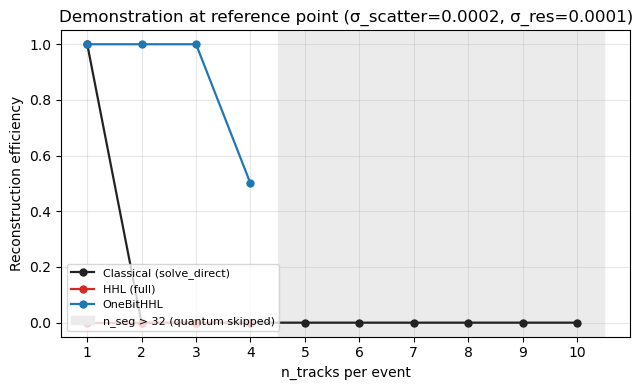

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))
for name in ALGOS:
    sub = demo_df[(demo_df["algorithm"] == name) & demo_df["ran"]]
    ax.plot(sub["n_tracks"], sub["efficiency"], "-o",
            color=ALGO_COLOURS[name], label=name, lw=1.6, ms=5)

cap = demo_df[(demo_df["algorithm"] == "HHL (full)") & ~demo_df["ran"]]
if not cap.empty:
    ax.axvspan(cap["n_tracks"].min() - 0.5, 10.5, color="0.92", zorder=0,
               label=f"HHL > {QUANTUM_WALL_S:g} s (timed out)")

ax.set_xticks(range(1, 11))
ax.set_xlabel("n_tracks per event"); ax.set_ylabel("Reconstruction efficiency")
ax.set_ylim(-0.05, 1.05); ax.grid(True, alpha=0.3)
ax.set_title(f"Demonstration at reference point "
             f"(σ_scatter={REF_SIGMA_SCATTER:g}, σ_res={REF_SIGMA_RES:g})")
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
fig.savefig(OUT / "plots" / "demo_efficiency_vs_ntracks.png", dpi=140)
plt.show()


In [9]:
def run_scan(param_name, param_values, *, n_tracks=REF_N_TRACKS,
             sigma_scatter=REF_SIGMA_SCATTER, sigma_res=REF_SIGMA_RES,
             n_events=N_EVENTS_SCAN):
    """Generic one-parameter scan. Returns tidy DataFrame (one row per algo per event)."""
    rows = []
    for v in param_values:
        kw = {"n_tracks": n_tracks,
              "sigma_scatter": sigma_scatter, "sigma_res": sigma_res}
        kw[param_name] = v
        for ei in range(n_events):
            ev, gen = generate_event(kw["n_tracks"],
                                     kw["sigma_scatter"], kw["sigma_res"])
            res = run_all_solvers(ev, gen,
                                  kw["sigma_scatter"], kw["sigma_res"])
            for name in ALGOS:
                r = res[name]
                rows.append({
                    "param":      param_name, "value": v, "event": ei,
                    "algorithm":  name,
                    "n_seg":      res["n_segments"],
                    "ran":        not r.get("skipped", False),
                    "efficiency": r.get("efficiency", float("nan")),
                    "ghost":      r.get("ghost_rate", float("nan")),
                    "purity":     r.get("purity", float("nan")),
                    "fidelity":   r.get("fidelity", float("nan")),
                    "time_s":     r.get("time", float("nan")),
                })
    return pd.DataFrame(rows)


def summary_table(df):
    """Mean ± std of efficiency / ghost / fidelity per (value, algorithm)."""
    agg = (df[df["ran"]]
           .groupby(["value", "algorithm"])
           .agg(eff_mean=("efficiency", "mean"),
                eff_std =("efficiency", "std"),
                ghost_mean=("ghost", "mean"),
                fid_mean =("fidelity", "mean"),
                n_ran=("efficiency", "count"))
           .reset_index())
    return agg


def plot_scan(df, param_name, *, xlabel, title, save_as, logx=True):
    agg = summary_table(df)
    fig, ax = plt.subplots(figsize=(6.5, 4.0))
    for name in ALGOS:
        sub = agg[agg["algorithm"] == name].sort_values("value")
        if sub.empty: continue
        ax.errorbar(sub["value"], sub["eff_mean"],
                    yerr=sub["eff_std"].fillna(0.0),
                    fmt="-o", color=ALGO_COLOURS[name], label=name,
                    lw=1.6, ms=5, capsize=3)
    if logx: ax.set_xscale("log")
    ax.set_xlabel(xlabel); ax.set_ylabel("Reconstruction efficiency")
    ax.set_ylim(-0.05, 1.05); ax.grid(True, which="both", alpha=0.3)
    ax.set_title(title); ax.legend(fontsize=8, loc="best")
    fig.tight_layout()
    fig.savefig(OUT / "plots" / save_as, dpi=140)
    plt.show()
    return agg


## 3. Scan A — σ<sub>scatter</sub>

Only `sigma_scatter` varies; `sigma_res` and `n_tracks` are held at the
reference values. Five events per point.


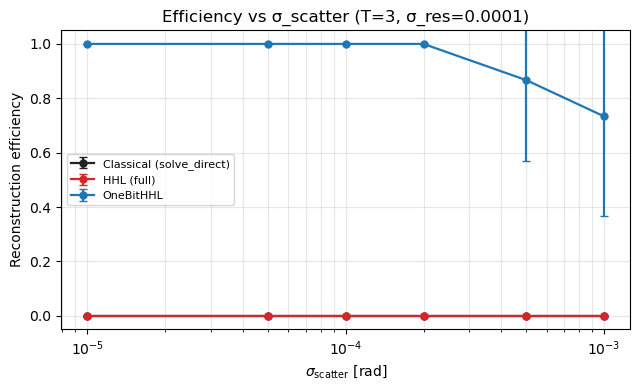

,value,algorithm,eff_mean,eff_std,ghost_mean,fid_mean,n_ran
0,0.000,Classical (solve_direct),0.000,0.000,1.0,1.000,5
1,0.000,HHL (full),0.000,0.000,0.2,0.414,5
2,0.000,OneBitHHL,1.000,0.000,0.0,0.684,5
3,0.000,Classical (solve_direct),0.000,0.000,1.0,1.000,5
4,0.000,HHL (full),0.000,0.000,0.2,0.399,5
5,0.000,OneBitHHL,1.000,0.000,0.0,0.684,5
6,0.000,Classical (solve_direct),0.000,0.000,1.0,1.000,5
7,0.000,HHL (full),0.000,0.000,0.0,NaN,5
8,0.000,OneBitHHL,1.000,0.000,0.0,0.685,5
9,0.000,Classical (solve_direct),0.000,0.000,1.0,1.000,5


In [10]:
SIGMA_SCATTER_VALUES = [1e-5, 5e-5, 1e-4, 2e-4, 5e-4, 1e-3]
scanA = run_scan("sigma_scatter", SIGMA_SCATTER_VALUES)
scanA.to_csv(OUT / "scanA_sigma_scatter.csv", index=False)
aggA = plot_scan(scanA, "sigma_scatter",
                 xlabel=r"$\sigma_{\mathrm{scatter}}$ [rad]",
                 title=f"Efficiency vs σ_scatter (T={REF_N_TRACKS}, "
                       f"σ_res={REF_SIGMA_RES:g})",
                 save_as="scanA_efficiency_vs_sigma_scatter.png")
aggA.round(3)


## 4. Scan B — σ<sub>res</sub>

Only `sigma_res` (hit measurement error) varies.


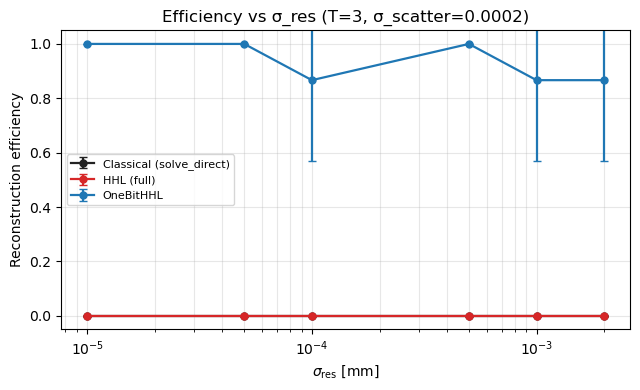

,value,algorithm,eff_mean,eff_std,ghost_mean,fid_mean,n_ran
0,0.000,Classical (solve_direct),0.000,0.000,1.0,1.000,5
1,0.000,HHL (full),0.000,0.000,0.0,NaN,5
2,0.000,OneBitHHL,1.000,0.000,0.0,0.684,5
3,0.000,Classical (solve_direct),0.000,0.000,1.0,1.000,5
4,0.000,HHL (full),0.000,0.000,0.4,0.414,5
5,0.000,OneBitHHL,1.000,0.000,0.0,0.685,5
6,0.000,Classical (solve_direct),0.000,0.000,1.0,1.000,5
7,0.000,HHL (full),0.000,0.000,0.4,0.399,5
8,0.000,OneBitHHL,0.867,0.298,0.1,0.705,5
9,0.000,Classical (solve_direct),0.000,0.000,1.0,1.000,5


In [11]:
SIGMA_RES_VALUES = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 2e-3]
scanB = run_scan("sigma_res", SIGMA_RES_VALUES)
scanB.to_csv(OUT / "scanB_sigma_res.csv", index=False)
aggB = plot_scan(scanB, "sigma_res",
                 xlabel=r"$\sigma_{\mathrm{res}}$ [mm]",
                 title=f"Efficiency vs σ_res (T={REF_N_TRACKS}, "
                       f"σ_scatter={REF_SIGMA_SCATTER:g})",
                 save_as="scanB_efficiency_vs_sigma_res.png")
aggB.round(3)


## 5. Scan C — number of tracks

Only `n_tracks` varies, $1 \le T \le 10$, at the reference noise.


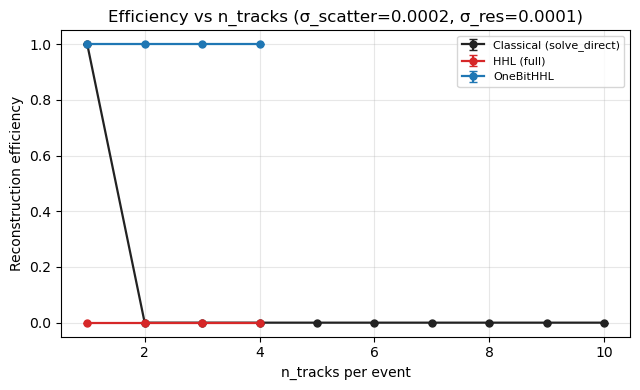

,value,algorithm,eff_mean,eff_std,ghost_mean,fid_mean,n_ran
0,1,Classical (solve_direct),1.0,0.0,0.0,1.000,5
1,1,HHL (full),0.0,0.0,0.0,NaN,5
2,1,OneBitHHL,1.0,0.0,0.0,1.000,5
3,2,Classical (solve_direct),0.0,0.0,1.0,1.000,5
4,2,HHL (full),0.0,0.0,0.0,NaN,5
5,2,OneBitHHL,1.0,0.0,0.0,0.799,5
6,3,Classical (solve_direct),0.0,0.0,1.0,1.000,5
7,3,HHL (full),0.0,0.0,0.0,NaN,5
8,3,OneBitHHL,1.0,0.0,0.0,0.684,5
9,4,Classical (solve_direct),0.0,0.0,1.0,1.000,5


In [12]:
NTRACKS_VALUES = list(range(1, 11))
scanC = run_scan("n_tracks", NTRACKS_VALUES)
scanC.to_csv(OUT / "scanC_ntracks.csv", index=False)
aggC = plot_scan(scanC, "n_tracks",
                 xlabel="n_tracks per event",
                 title=f"Efficiency vs n_tracks "
                       f"(σ_scatter={REF_SIGMA_SCATTER:g}, "
                       f"σ_res={REF_SIGMA_RES:g})",
                 save_as="scanC_efficiency_vs_ntracks.png",
                 logx=False)
aggC.round(3)


## 6. Example events — well vs poorly reconstructed

Both panels are drawn from the §2 demonstration events (reference
noise). We pick:

- **Good**: the largest $T$ where *every* algorithm achieves
  efficiency $\ge 0.9$.
- **Bad**: the $T$ where `HHL (full)` attains the lowest fidelity
  against the classical solution (i.e. the quantum output is most
  distorted).


Good example : T = None
Bad example  : T = 4  (HHL fidelity = 0.363)


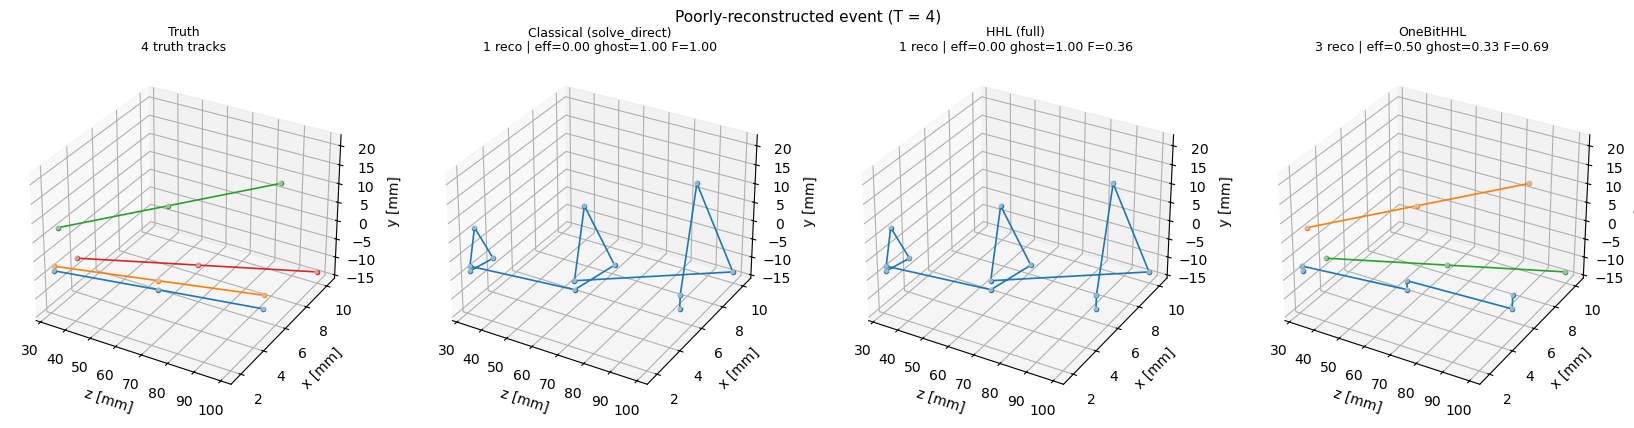

In [13]:
def _eff(res, name):
    r = res.get(name, {})
    return -1.0 if r.get("skipped", False) else r.get("efficiency", 0.0)


# ---- good: largest T with efficiency ≥ 0.9 for all algos that ran ----
good_T = None
for T in sorted(demo_events, reverse=True):
    _, res = demo_events[T]
    ran = [n for n in ALGOS if not res[n].get("skipped", False)]
    if ran and all(_eff(res, n) >= 0.9 for n in ran):
        good_T = T; break

# ---- bad: lowest HHL fidelity among events where HHL ran ----
bad_T, worst = None, float("inf")
for T, (_, res) in demo_events.items():
    r = res.get("HHL (full)", {})
    if r.get("skipped", False): continue
    f = r.get("fidelity", float("nan"))
    if np.isfinite(f) and f < worst:
        worst, bad_T = f, T
if bad_T is None:  # HHL never ran → fall back to worst-efficiency event
    bad_T = min(demo_events,
                key=lambda T: demo_events[T][1]["Classical (solve_direct)"]["efficiency"])

print(f"Good example : T = {good_T}")
print(f"Bad example  : T = {bad_T}  (HHL fidelity = {worst:.3f})")

if good_T is not None:
    ev, res = demo_events[good_T]
    plot_event_panel(ev, res,
                     title=f"Well-reconstructed event (T = {good_T})",
                     save_as=f"example_good_T{good_T}.png")

ev, res = demo_events[bad_T]
plot_event_panel(ev, res,
                 title=f"Poorly-reconstructed event (T = {bad_T})",
                 save_as=f"example_bad_T{bad_T}.png")


## 7. Where things stand

- **Classical baseline** (`solve_direct`) is the reference efficiency curve.
- **HHL (full)** and **OneBitHHL** are each allocated a wall-time budget
  of `QUANTUM_WALL_S = 30 s` per inversion. Runs exceeding this budget
  are aborted via `SIGALRM`, reported with `skipped=True`, and shaded on
  the plots.
- Every scan varies a single parameter and reports mean ± std over
  `N_EVENTS_SCAN` events; CSVs are in `outputs/first_bench/`, figures in
  `outputs/first_bench/plots/`.

Caveats: small sample (5 events/point), no explicit seed sweep per
event, quantum simulators are statevector/shot-based — not real
hardware noise. This notebook is an *initial* benchmark only.


## 8. Quantum 1BQF analysis — `OneBQF` from upstream repo

Direct port of the §18 *Quantum (1BQF / `OneBitHHL`)* sections of
`Toy_Characterisation/Verify_new_results/segment_level_analysis.ipynb`,
**replacing** the `lhcb_velo_toy.solvers.quantum.one_bit_hhl.OneBitHHL`
class with the canonical [`OneBQF`](OneBQF/quantum_algorithms/OneBQF.py)
class checked out from
<https://github.com/GeorgeWilliam1999/OneBQF.git>.

The repo's `OneBQF.get_solution` does not actually return the
recovered amplitudes (it computes `solution_padded` and falls off the
end of the function), so we re-implement the post-selection extraction
inline in `solve_obqf_repo`. Algorithmically identical: cosine of
$\sqrt{P(\text{ancilla}=1, \text{system}=i)}$ on the padded basis.

### Comparison methodology (from §18)

Classical solver returns signed activations $s_C \in \mathbb{R}^{n_\mathrm{seg}}$;
quantum returns unit-norm amplitudes $s_Q$. Fair apples-to-apples:

- **Scale-invariant fidelity**: cosine $\langle s_Q, s_C\rangle / (\|s_Q\|\|s_C\|)$,
  relative L2, Jaccard of active sets after rescaling $\tilde s_Q = s_Q \cdot \|s_C\|_2$.
- **Thresholded metrics**: rescale $\tilde s_Q$, apply the same
  paper threshold $\tau = 0.45 \cdot \max(|s|)$, feed through `get_tracks`.


In [ ]:
# ── Import OneBQF directly from the upstream repo clone ──────────
import sys, time as _time18
from pathlib import Path as _Path

_ONEBQF_ROOT = _Path("/data/bfys/gscriven/Quantum_Track_Reconstruction/"
                     "Toy_Characterisation/Quantum_Toy_Study/OneBQF")
if not _ONEBQF_ROOT.exists():
    raise FileNotFoundError(
        f"Expected OneBQF.git checkout at {_ONEBQF_ROOT}.  "
        "Run: git clone https://github.com/GeorgeWilliam1999/OneBQF.git "
        f"{_ONEBQF_ROOT}")
if str(_ONEBQF_ROOT) not in sys.path:
    sys.path.insert(0, str(_ONEBQF_ROOT))

from quantum_algorithms.OneBQF import OneBQF as _OneBQFRepo   # noqa: E402

import inspect as _inspect
print(f"OneBQF source : {_inspect.getfile(_OneBQFRepo)}")
print(f"signature     : OneBQF{_inspect.signature(_OneBQFRepo.__init__)}")


# ── Quantum solver: drives the upstream OneBQF and extracts ──────
#    the solution from counts (upstream get_solution is broken — it
#    computes `solution_padded` then falls off the end without a
#    return statement, so we redo the post-selection here).
OBQF_REPO_SHOTS = OBQF_SHOTS   # reuse the §0 budget

def solve_obqf_repo(A, b, shots: int = OBQF_REPO_SHOTS):
    """Drive the upstream `OneBQF` solver and return the recovered
    amplitudes on the *original* (un-padded) segment register."""
    A_d = np.asarray(A.toarray() if hasattr(A, "toarray") else A, dtype=float)
    b_d = np.asarray(b, dtype=float).ravel()
    t0 = _time18.time()
    with time_budget(QUANTUM_WALL_S):
        obqf = _OneBQFRepo(A_d, b_d, num_time_qubits=1, shots=shots)
        obqf.build_circuit()
        counts = obqf.run(use_noise_model=False)

        n_qsys      = obqf.num_system_qubits
        padded_dim  = 2 ** n_qsys
        prob_dist   = np.zeros(padded_dim)
        n_success   = 0
        for outcome, c in counts.items():
            # Qiskit returns space-separated registers; flatten then
            # take the ancilla bit (rightmost) as in upstream.
            bits = outcome.replace(" ", "")
            if bits[-1] != "1":
                continue
            idx = int(bits[:-1], 2)
            prob_dist[idx] += c
            n_success    += c

        if n_success == 0:
            sol_padded = np.zeros(padded_dim)
            success_prob = 0.0
        else:
            prob_dist /= prob_dist.sum()
            sol_padded = np.sqrt(prob_dist)
            sol_padded /= np.linalg.norm(sol_padded)
            success_prob = n_success / shots

    dt = _time18.time() - t0
    sol = sol_padded[: A_d.shape[0]]
    return sol, dt, success_prob


def segment_fidelity(sol_C, sol_Q):
    """§18-style segment-fidelity bundle: cosine, relative L2, and
    Jaccard of the τ = 0.45·max(|s|) active sets (rescaled sQ)."""
    sC = np.asarray(sol_C).ravel()
    sQ = np.asarray(sol_Q).ravel()
    n  = min(sC.size, sQ.size)
    sC, sQ = sC[:n], sQ[:n]

    nC = np.linalg.norm(sC)
    nQ = np.linalg.norm(sQ)
    cos = float(np.dot(sC, sQ) / (nC * nQ)) if nC > 0 and nQ > 0 else float("nan")

    # Rescale sQ so its L2 matches sC, then threshold both at 0.45·max
    sQ_scaled = sQ * (nC / nQ) if nQ > 0 else sQ
    rel_l2    = float(np.linalg.norm(sQ_scaled - sC) / max(nC, 1e-12))

    tauC  = sC        > _active_threshold(sC)
    tauQ  = sQ_scaled > _active_threshold(sQ_scaled)
    inter = int(np.sum(tauC & tauQ))
    union = int(np.sum(tauC | tauQ))
    jacc  = inter / union if union > 0 else 1.0
    return {"cos": cos, "rel_l2": rel_l2, "jaccard": jacc,
            "n_active_C": int(tauC.sum()), "n_active_Q": int(tauQ.sum()),
            "sQ_scaled": sQ_scaled}


print("§8 helpers ready: solve_obqf_repo, segment_fidelity")


In [ ]:
# ============================================================
# §8a — small-n quantum sweep with upstream OneBQF
# ============================================================
# Mirrors §18a of segment_level_analysis.ipynb but uses
# `solve_obqf_repo` (upstream OneBQF.git) instead of the local
# `OneBitHHL` port and the existing notebook helpers (Hamiltonian,
# generator, validator) for everything else.
#
# Scope:  T ∈ N_TRK_18A, with N_REPS_18A repetitions per point.
# Per-event walltime on CPU: seconds at T=2 → up to a couple of
# minutes by T=6.
N_TRK_18A   = [2, 3, 4, 5, 6]
N_REPS_18A  = 3

q_records = []         # tidy DataFrame rows for plots / CSV
q_events  = {}         # (T, rep) -> dict for solution scatter

for T in N_TRK_18A:
    for rep in range(N_REPS_18A):
        np.random.seed(rep + T * 100 + 140000)   # §18 seed convention
        ev, gen = generate_event(T, REF_SIGMA_SCATTER, REF_SIGMA_RES)

        A, b, ham, eps = build_step_hamiltonian(
            gen, REF_SIGMA_SCATTER, REF_SIGMA_RES)

        # ------------- classical reference -------------
        sol_C, t_C = solve_classical(A, b)
        m_C = track_metrics(ev, ham, sol_C)

        # ------------- quantum (upstream OneBQF) -------
        try:
            sol_Q_raw, t_Q, p_succ = solve_obqf_repo(A, b)
            skipped, err = False, None
        except _Timeout as exc:
            sol_Q_raw, t_Q, p_succ = None, QUANTUM_WALL_S, float("nan")
            skipped, err = True, f"timeout: {exc}"
        except Exception as exc:
            sol_Q_raw, t_Q, p_succ = None, float("nan"), float("nan")
            skipped, err = True, repr(exc)

        if not skipped:
            fid = segment_fidelity(sol_C, sol_Q_raw)
            sQ_scaled = fid["sQ_scaled"]
            m_Q = track_metrics(ev, ham, sQ_scaled)
        else:
            fid = {"cos": float("nan"), "rel_l2": float("nan"),
                   "jaccard": float("nan"),
                   "n_active_C": int((sol_C > _active_threshold(sol_C)).sum()),
                   "n_active_Q": 0, "sQ_scaled": None}
            m_Q = {"efficiency": float("nan"), "ghost_rate": float("nan"),
                   "purity": float("nan"), "n_reco": 0,
                   "reco_tracks": [], "threshold": float("nan")}

        q_events[(T, rep)] = {
            "ev": ev, "ham": ham, "A": A, "b": b,
            "sol_C": sol_C, "sol_Q_raw": sol_Q_raw,
            "sQ_scaled": fid["sQ_scaled"],
            "fid": fid, "m_C": m_C, "m_Q": m_Q,
            "t_C": t_C, "t_Q": t_Q, "p_succ": p_succ,
            "skipped": skipped, "err": err,
        }
        q_records.append({
            "T": T, "rep": rep, "n_seg": ham.n_segments,
            "n_qsys": int(np.ceil(np.log2(max(ham.n_segments, 2)))),
            "ran": not skipped,
            "cos": fid["cos"], "rel_l2": fid["rel_l2"],
            "jaccard": fid["jaccard"],
            "p_succ": p_succ, "t_quantum": t_Q, "t_classical": t_C,
            "eff_C": m_C["efficiency"], "eff_Q": m_Q["efficiency"],
            "ghost_C": m_C["ghost_rate"], "ghost_Q": m_Q["ghost_rate"],
        })
        tag = "OK " if not skipped else "SKIP"
        print(f"  T={T} rep={rep}  n_seg={ham.n_segments:4d}  "
              f"cos={fid['cos']:.3f}  Jacc={fid['jaccard']:.3f}  "
              f"P(anc=1)={p_succ:.3f}  "
              f"eff_Q={m_Q['efficiency']:.2f}  eff_C={m_C['efficiency']:.2f}  "
              f"({t_Q:.1f}s)  [{tag}]")

q_df = pd.DataFrame(q_records)
q_df.to_csv(OUT / "section8_obqf_repo_smalln.csv", index=False)
q_df


In [ ]:
# ============================================================
# §8a plots — fidelity, scatter, success/walltime
# ============================================================
ran = q_df[q_df["ran"]].copy()
if ran.empty:
    print("No quantum events ran — nothing to plot.")
else:
    agg = (ran.groupby("T")
              .agg(cos_m=("cos", "mean"),     cos_s=("cos", "std"),
                   jac_m=("jaccard", "mean"), jac_s=("jaccard", "std"),
                   eff_C=("eff_C", "mean"),   eff_Q=("eff_Q", "mean"),
                   p_m=("p_succ", "mean"),    t_m=("t_quantum", "mean"))
              .reset_index())

    fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.6))

    # (a) segment-level fidelity vs T
    ax = axes[0, 0]
    ax.errorbar(agg["T"], agg["cos_m"], yerr=agg["cos_s"].fillna(0),
                fmt="-o", color="#1f77b4",
                label=r"$\cos(s_Q, s_C)$", capsize=3)
    ax.errorbar(agg["T"], agg["jac_m"], yerr=agg["jac_s"].fillna(0),
                fmt="-s", color="#d62728",
                label=r"Jaccard ($\tau$=0.45·max)", capsize=3)
    ax.set_xlabel("n_tracks"); ax.set_ylabel("fidelity")
    ax.set_ylim(0, 1.05); ax.grid(alpha=0.3); ax.legend()
    ax.set_title("Segment-level fidelity (OneBQF vs classical)")

    # (b) track-level efficiency C vs Q
    ax = axes[0, 1]
    ax.plot(agg["T"], agg["eff_C"], "-s", color="#2ca02c",
            label="classical")
    ax.plot(agg["T"], agg["eff_Q"], "--o", color="#1f77b4",
            label="OneBQF")
    ax.set_xlabel("n_tracks"); ax.set_ylabel("Reconstruction efficiency")
    ax.set_ylim(-0.05, 1.05); ax.grid(alpha=0.3); ax.legend()
    ax.set_title("Track-level efficiency")

    # (c) solution scatter at largest successful T (rep 0)
    ax = axes[1, 0]
    Tbig = int(ran["T"].max())
    rec  = q_events.get((Tbig, 0))
    if rec is not None and rec["sQ_scaled"] is not None:
        sC, sQ = rec["sol_C"], rec["sQ_scaled"]
        thr = _active_threshold(sC)
        m = sC > thr
        ax.scatter(sC[~m], sQ[~m], s=8, alpha=0.4, color="#7f7f7f",
                   label="false")
        ax.scatter(sC[m],  sQ[m],  s=10, alpha=0.8, color="#2ca02c",
                   label="true")
        lo = float(min(sC.min(), sQ.min()))
        hi = float(max(sC.max(), sQ.max()))
        ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.5)
        ax.axvline(thr, color="red", ls=":", lw=0.8, alpha=0.6)
        ax.axhline(thr, color="red", ls=":", lw=0.8, alpha=0.6)
        ax.set_xlabel(r"classical $s_C$")
        ax.set_ylabel(r"OneBQF $\tilde s_Q$ (rescaled)")
        ax.set_title(f"Solution scatter at T = {Tbig} (rep 0)")
        ax.legend(fontsize=9); ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, "no successful run", ha="center", va="center")
        ax.set_axis_off()

    # (d) post-selection success and quantum walltime
    ax = axes[1, 1]
    ax.plot(agg["T"], agg["p_m"], "-o", color="#1f77b4",
            label="P(ancilla=1)")
    ax.set_xlabel("n_tracks")
    ax.set_ylabel("post-select success", color="#1f77b4")
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis="y", labelcolor="#1f77b4")
    ax.grid(alpha=0.3)
    ax2 = ax.twinx()
    ax2.plot(agg["T"], agg["t_m"], "-s", color="#ff7f0e",
             label="quantum wall [s]")
    ax2.set_ylabel("quantum wall time [s]", color="#ff7f0e")
    ax2.tick_params(axis="y", labelcolor="#ff7f0e")
    ax.set_title("Post-selection & walltime")

    fig.suptitle(
        f"§8a — upstream OneBQF vs classical at small T  "
        f"(shots={OBQF_REPO_SHOTS}, reps={N_REPS_18A})", fontsize=12)
    fig.tight_layout()
    fig.savefig(OUT / "plots" / "section8a_obqf_repo_smalln.png", dpi=140,
                bbox_inches="tight")
    plt.show()


In [ ]:
# ============================================================
# §8b — summary table (means only)
# ============================================================
print(f"{'T':>3} | {'n_seg':>6} {'qubits':>7}  "
      f"{'cos':>6} {'rel_L2':>7} {'Jacc':>6}  {'P(anc=1)':>9}  "
      f"{'eff_C':>6} {'eff_Q':>6}  {'t_Q[s]':>7}")
print("-" * 80)
for T in sorted(set(q_df["T"])):
    sub = q_df[(q_df["T"] == T) & q_df["ran"]]
    if sub.empty:
        n_seg = q_df[q_df["T"] == T]["n_seg"].iloc[0]
        nqs   = q_df[q_df["T"] == T]["n_qsys"].iloc[0]
        print(f"{T:3d} | {n_seg:6d} {nqs:4d}+2  (all skipped)")
        continue
    n_seg = sub["n_seg"].iloc[0]
    nqs   = sub["n_qsys"].iloc[0]
    print(f"{T:3d} | {n_seg:6d} {nqs:4d}+2  "
          f"{sub['cos'].mean():6.3f} {sub['rel_l2'].mean():7.3f} "
          f"{sub['jaccard'].mean():6.3f}  "
          f"{sub['p_succ'].mean():9.3f}  "
          f"{sub['eff_C'].mean():6.2f} {sub['eff_Q'].mean():6.2f}  "
          f"{sub['t_quantum'].mean():7.1f}")
